Lets see how two alanine molecules orient themselves using CREST conformer generation.
To do this we will constrain the system in a spherical region using the `SphericalWall` constraint.
We start by setting up a system of two alanine molecules in a relatively small space.

## Initial imports

In [1]:
import scm.plams as plams
import sys
from scm.conformers import ConformersJob
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from scm.plams import view  # view molecule using AMSview in a Jupyter Notebook in AMS2026+

    _has_view = True
except ImportError:
    from scm.plams import plot_molecule  # plot molecule in a Jupyter Notebook in AMS2023+

    _has_view = False

    def view(molecule, ax=None, **kwargs):
        plot_molecule(molecule, ax=ax)


# this line is not required in AMS2025+
plams.init();

PLAMS working folder: /path/plams/examples/ConformersMultipleMolecules/plams_workdir


## Single alanine molecule

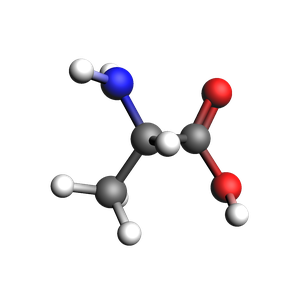

In [2]:
smiles = "CC(N)C(=O)O"
alanine = plams.from_smiles(smiles)
view(alanine, height=300, width=300)

## Initial system: alanine dimer

Pack two alanine molecules in a sphere with a density of 0.5 kg/L.

In [3]:
density = 0.5
mol = plams.packmol(alanine, n_molecules=2, density=density, sphere=True)

Translate the molecule to be centered around the origin (needed for SphericalWall later):

In [4]:
mol.translate(-np.array(mol.get_center_of_mass()))

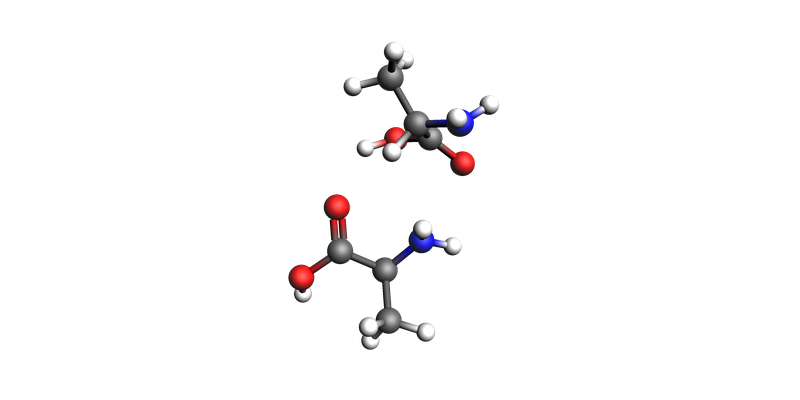

In [5]:
view(mol, direction="along_pca3")

## Calculation setup

To determine the radius of the `SphericalWall` we measure the size of the initial dimer.

In [6]:
dists = plams.distance_array(mol, mol)
max_dist = np.max(dists)
diameter = 1.33 * max_dist
radius = diameter / 2
print(f"Largest distance between atoms: {max_dist:.3f} ang.")
print(f"Radius: {radius:.3f} ang.")

Largest distance between atoms: 8.361 ang.
Radius: 5.560 ang.


Now we can set up the Crest conformer generation job, with the appropriate spherical wall constraining the molecules close together. 

In [7]:
settings = plams.Settings()
settings.input.ams.EngineAddons.WallPotential.Enabled = "Yes"
settings.input.ams.EngineAddons.WallPotential.Radius = radius
settings.input.ams.Generator.Method = "CREST"
settings.input.ams.Output.KeepWorkDir = "Yes"
settings.input.ams.GeometryOptimization.MaxConvergenceTime = "High"
settings.input.ams.Generator.CREST.NCycles = 3  # at most 3 CREST cycles for this demo
settings.input.GFNFF = plams.Settings()

## Run the conformers job

Now we can run the conformer generation job.

In [8]:
job = ConformersJob(molecule=mol, settings=settings)
job.run()
# ConformersJob.load_external("plams_workdir/conformers/conformers.rkf")  # load from disk instead of running the job

[12.01|12:36:00] JOB conformers STARTED
[12.01|12:36:00] JOB conformers RUNNING
[12.01|12:41:35] JOB conformers FINISHED
[12.01|12:41:35] JOB conformers SUCCESSFUL


In [9]:
rkf = job.results.rkfpath()
print(f"Conformers stored in {rkf}")

Conformers stored in /path/plams/examples/ConformersMultipleMolecules/plams_workdir/conformers/conformers.rkf


This job will run for approximately 15 minutes.

## Results
Here we plot the three lowest-energy conformers.

In [15]:
def plot_conformers(job: ConformersJob, indices=None, temperature=298, unit="kcal/mol", lowest=True):
    molecules = job.results.get_conformers()
    energies = job.results.get_relative_energies(unit)
    populations = job.results.get_boltzmann_distribution(temperature)

    if isinstance(indices, int):
        N_plot = min(indices, len(energies))
        if lowest:
            indices = list(range(N_plot))
        else:
            indices = np.linspace(0, len(energies) - 1, N_plot, dtype=np.int32)
    if indices is None:
        indices = list(range(min(3, len(energies))))

    fig, axes = plt.subplots(1, len(indices), figsize=(12, 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, i in zip(axes, indices):
        mol = molecules[i]
        E = energies[i]
        population = populations[i]

        if _has_view:
            img = view(mol, width=300, height=300)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")
        else:
            view(mol, ax=ax)
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")

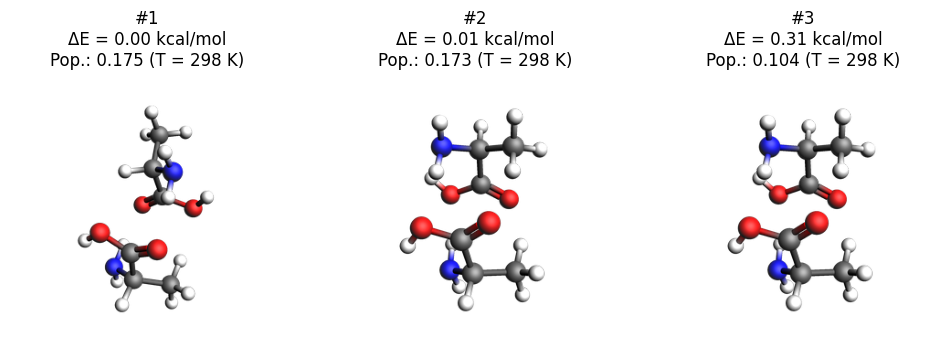

In [16]:
plot_conformers(job)

You can also open the conformers in AMSmovie to browse all conformers 1000+ conformers:

In [11]:
!amsmovie {rkf}

Finally in AMS2025+, you can also inspect the conformer data using the JobAnalysis tool.

In [12]:
try:
    from scm.plams import JobAnalysis

    ja = (
        JobAnalysis(standard_fields=None)
        .add_job(job)
        .add_field(
            "Id",
            lambda j: list(range(1, len(j.results.get_conformers()) + 1)),
            display_name="Conformer Id",
            expansion_depth=1,
        )
        .add_field(
            "Energies",
            lambda j: j.results.get_relative_energies("kcal/mol"),
            display_name="E",
            expansion_depth=1,
            fmt=".2f",
        )
        .add_field(
            "Populations",
            lambda j: j.results.get_boltzmann_distribution(298),
            display_name="P",
            expansion_depth=1,
            fmt=".3f",
        )
    )

    # Pretty-print if running in a notebook
    if "ipykernel" in sys.modules:
        ja.display_table(max_rows=20)
    else:
        print(ja.to_table())

except ImportError:
    pass

| Conformer Id | E      | P     |
|--------------|--------|-------|
| 1            | 0.00   | 0.175 |
| 2            | 0.01   | 0.173 |
| 3            | 0.31   | 0.104 |
| 4            | 0.33   | 0.100 |
| 5            | 0.59   | 0.065 |
| 6            | 0.87   | 0.040 |
| 7            | 0.89   | 0.039 |
| 8            | 1.10   | 0.028 |
| 9            | 1.14   | 0.026 |
| 10           | 1.36   | 0.018 |
| ...          | ...    | ...   |
| 1062         | 256.89 | 0.000 |
| 1063         | 306.67 | 0.000 |
| 1064         | 326.40 | 0.000 |
| 1065         | 369.67 | 0.000 |
| 1066         | 371.07 | 0.000 |
| 1067         | 415.00 | 0.000 |
| 1068         | 415.08 | 0.000 |
| 1069         | 470.42 | 0.000 |
| 1070         | 502.31 | 0.000 |
| 1071         | 666.28 | 0.000 |